# 00: 量子断熱計算による最適化シミュレーション
### (Optimization via Adiabatic Quantum Computation)

---

## 1. Thesis: 科学的問いと仮説
量子コンピュータを用いて組み合わせ最適化問題を解く際、近似的な手法（QAOAなど）ではなく、物理的な「断熱プロセス」を忠実にたどることで、より高い確率で厳密解に到達できます。

**問い**: 特定のアルゴリズム（ゲート操作の組み合わせ）に依存せず、ハミルトニアン（エネルギー）の物理的な遷移をシミュレーションすることで、最適化問題を解くための本質的なプロセスをどう記述できるか？

**仮説**: 初期ハミルトニアン $H_{start}$（全探索状態）から目的ハミルトニアン $H_{target}$（問題の制約）へ、「エネルギーギャップ」を意識しながら十分ゆっくりと遷移させることで、システムの基底状態を維持し、最終的に最適解を得ることができる。

## 2. Theoretical Background (理論的背景)

### 2.1 断熱定理 (Adiabatic Theorem)
物理学における断熱定理は、「システムのハミルトニアンが十分にゆっくりと変化する場合、システムはその時点での基底状態を維持し続ける」というものです。これを利用し、最初は誰でも答えがわかる単純な状態からスタートし、徐々に複雑な問題へと「すり替えていく」のが断熱量子計算の肝です。

### 2.2 ハミルトニアンの構成
シミュレーションで使用する全ハミルトニアン $H(t)$ は以下の2つの項の線形結合で表されます。

$$ H(t) = A(t)H_{start} + B(t)H_{target} $$

**$H_{start}$** : 
全ビットに対する $X$ ゲートの和。
すべてのビットを $|+\rangle$ 状態（0と1の重ね合わせ）に強制し、量子的な「揺らぎ」を与えます。

**$H_{target}$** : 
解きたい問題を $Z$ ゲートや $Z_i Z_j$ の相互作用で表現したもの。
このハミルトニアンのエネルギーが最小（基底状態）になる状態が、問題の正解となります。

### 2.3 トロッター分解による時間発展
連続的な時間変化をゲート方式の量子コンピュータで再現するため、全体の時間 $T$ を細かなステップ $\Delta t$ に分割します。各ステップで $RX$ ゲート（$H_{start}$）と $RZ/CX$ ゲート（$H_{target}$）を交互に適用することで、連続的な物理現象を近似的にシミュレーションします。

## 3. Implementation (実装)
外部ライブラリ "Qiskit" から `AerSimulator`、`QuantumCircuit` 、`transpile` をインポートします。

## 4. Visualization & Analysis (可視化と解析)

位相の変化が量子状態の測定結果にどのような影響を及ぼしているのかを可視化します。

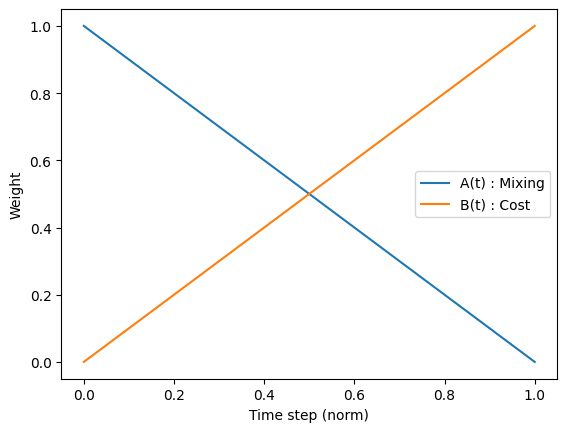

回路の深さ: 282
測定結果: {'010': 530, '101': 492, '111': 1, '011': 1}


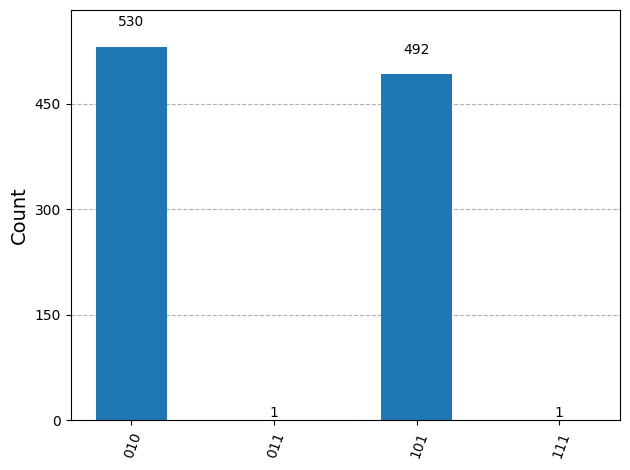

In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt
import numpy as np

from qiskit.visualization import plot_histogram

# 3量子ビットの準備
num_qubits = 3
edges = [(0, 1), (1, 2)]
# 目標ハミルトニアンの定義（ここでは概念的なリストとして）
# H_target = Z0*Z1 + Z1*Z2

# 1. グラフの定義 (0 -- 1 -- 2)
# このグラフの最大カット（1だけ違う組にする）を、断熱計算で見つけます。
adj_matrix = np.array([
    [0, 1, 0],
    [1, 0, 1],
    [0, 1, 0]
])
num_qubits = len(adj_matrix)
edges = [(0, 1), (1, 2)]

# 2. シミュレーション全体のパラメータ
T = 10.0      # 全体の時間（アニーリング時間）。大きいほど「ゆっくり」
N = 40        # ステップ数。大きいほど「なめらか」
dt = T / N    # 1ステップあたりの時間

# 0から1までをNステップ分、均等に割る
s_values = np.linspace(0, 1, N + 1)

# A(t) は 1.0 から 0.0 へ
A_schedule = 1 - s_values
# B(t) は 0.0 から 1.0 へ
B_schedule = s_values

# グラフにして確認
plt.plot(s_values, A_schedule, label="A(t) : $H_{start}$")
plt.plot(s_values, B_schedule, label="B(t) : $H_{target}$")
plt.xlabel("Time (norm)")
plt.ylabel("Weight")
plt.legend()
plt.show()

# 量子回路の初期化（3量子ビット）
qc = QuantumCircuit(num_qubits)

# 1. 初期状態の作成 (全ビットを |+> に)
qc.h(range(num_qubits))
qc.barrier()

# 2. 時間発展のループ (Nステップ)
for step in range(N):
    A = A_schedule[step]
    B = B_schedule[step]
    
    # --- (A) Mixing Hamiltonian (X項): 符号を反転させる ---
    for i in range(num_qubits):
        # 正解を追うために -2 をかける
        qc.rx(-2 * A * dt, i) 
    
    # --- (B) Cost Hamiltonian (Z項): そのまま ---
    for i, j in edges:
        qc.cx(i, j)
        qc.rz(2 * B * dt, j)
        qc.cx(i, j)
        
    qc.barrier()

# 3. 最後に測定
qc.measure_all()

# 回路の深さを確認（かなり長くなります）
print(f"回路の深さ: {qc.depth()}")

# シミュレータの準備
sim = AerSimulator()
qc_compiled = transpile(qc, sim)
# 実行（shotsは測定回数。多いほど確率分布が正確になります）
result = sim.run(qc_compiled, shots=1024).result()
counts = result.get_counts()
# 結果のヒストグラムを表示
print("測定結果:", counts)
plot_histogram(counts)

## 5. Conclusion & Future Work (結論と展望)
### 結論
本ノートブックでは、量子センシングの基礎となる $H - R_Z(\theta) - H$ 回路（ラムゼー干渉計）の動作を検証しました。以下の3点が明らかになりました：

1. **位相のマッピング**: RZゲート単独では隠蔽されている位相情報が、2度のHadamardゲートで挟むことで「測定確率」へと写像されることが実証されました。 

2. **理論との整合性**: シミュレーション結果は理論式 $P(0) = \cos^2(\theta/2)$ と極めて高い精度で一致しました。

3. **確率の収束**: 量子は確率的な挙動をするので誤差は発生しますが、測定回数を増やすことで確率が収束していくプロセスが確認できました。


### 展望
- **反復位相推定 (IPE)**: 1ビットずつ高精度に位相を決定していくアルゴリズムを導入し、測定レンジと精度のトレードオフを解消します。 

- **フィードバック制御の高度化**: 今回式の導出で明らかになった、近傍で確率が大きく変わる位相($= π/2$)を活用し、環境による変動がある中でどうやって状態を維持し続けるか、制御工学的アプローチ（PID 制御など）を用いて模索します。

- **ノイズ耐性の評価**: デコヒーレンス（量子情報の消失）が存在する現実的な環境下での、測定感度の限界（ハイゼンベルク限界など）について考察を深めます。